In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [76]:
RANDOM_STATE = 42

PLOT_SAMPLE_SIZE = 50000
SCORE_SAMPLE_SIZE = 20000
EVAL_FEATURE_SET_SAMPLE_SIZE = 20000

K_RANGE = range(1, 21)
K_RANGE_SIL = range(2, 21)

BEST_K = None

In [77]:
df = pd.read_csv("Divar.csv", low_memory=False)

In [78]:
print(df.shape)

(1000000, 61)


In [148]:
cols = [
    "price_value",
    "building_size",
    "rooms_count",
    "location_latitude",
    "location_longitude",
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "has_pool",
    "has_heating_system",
    "has_cooling_system"
]

In [149]:
df_rec = df[cols].copy()

In [150]:
print(df_rec.info())
print(df_rec.isna().sum())
print(df_rec.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price_value         568346 non-null  float64
 1   building_size       980394 non-null  float64
 2   rooms_count         845899 non-null  object 
 3   location_latitude   655608 non-null  float64
 4   location_longitude  655608 non-null  float64
 5   has_parking         728156 non-null  object 
 6   has_elevator        541749 non-null  object 
 7   has_warehouse       728155 non-null  object 
 8   has_balcony         506411 non-null  object 
 9   has_pool            29390 non-null   object 
 10  has_heating_system  368969 non-null  object 
 11  has_cooling_system  350619 non-null  object 
dtypes: float64(4), object(8)
memory usage: 91.6+ MB
None
price_value           431654
building_size          19606
rooms_count           154101
location_latitude     344392
location_longi

In [151]:
df_rec.head()

,price_value,building_size,rooms_count,location_latitude,location_longitude,has_parking,has_elevator,has_warehouse,has_balcony,has_pool,has_heating_system,has_cooling_system
0,NaN,500.0,سه,35.811684,50.936600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.500000e+09,60.0,یک,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN
2,NaN,132.0,سه,35.703865,51.373459,True,True,True,NaN,NaN,NaN,NaN
3,NaN,90.0,یک,NaN,NaN,True,True,False,NaN,NaN,NaN,NaN
4,5.750000e+09,115.0,دو,NaN,NaN,True,True,True,true,NaN,shoofaj,air_conditioner


In [152]:
room_map = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}

df_rec["rooms_count"] = df_rec["rooms_count"].map(room_map)

In [153]:
df_rec["rooms_count"].value_counts(dropna=False)

rooms_count
2.0    404050
1.0    192083
NaN    154101
3.0    138633
0.0     75898
4.0     21371
5.0     13864
Name: count, dtype: int64

In [155]:
bool_map = {
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
    "true": 1,
    "false": 0,
    "TRUE": 1,
    "FALSE": 0,
    1: 1,
    0: 0
}

bool_cols = [
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "has_pool",
    "has_heating_system",
    "has_cooling_system"
]

for col in bool_cols:
    df_rec[col] = df_rec[col].map(bool_map)

In [156]:
for col in bool_cols:
    print(df_rec[col].value_counts(dropna=False))

has_parking
1.0    552542
NaN    271844
0.0    175614
Name: count, dtype: int64
has_elevator
NaN    458251
1.0    365148
0.0    176601
Name: count, dtype: int64
has_warehouse
1.0    582313
NaN    271845
0.0    145842
Name: count, dtype: int64
has_balcony
NaN    493812
1.0    412788
0.0     93400
Name: count, dtype: int64
has_pool
NaN    970610
0.0     25669
1.0      3721
Name: count, dtype: int64
has_heating_system
NaN    1000000
Name: count, dtype: int64
has_cooling_system
NaN    1000000
Name: count, dtype: int64


In [157]:
df_rec.isna().sum()

price_value            431654
building_size           19606
rooms_count            154101
location_latitude      344392
location_longitude     344392
has_parking            271844
has_elevator           458251
has_warehouse          271845
has_balcony            493812
has_pool               970610
has_heating_system    1000000
has_cooling_system    1000000
dtype: int64

In [158]:
df_rec = df_rec.dropna(subset=[
    "location_latitude",
    "location_longitude"
]).copy()

df_rec.shape

(655608, 12)

In [159]:
df_rec = df_rec.dropna(subset=[
    "price_value"
]).copy()

df_rec.shape

(372119, 12)

In [160]:
df_rec = df_rec[df_rec["price_value"] > 0].copy()

df_rec.shape

(370915, 12)

In [161]:
df_rec = df_rec[df_rec["price_value"] >= 100_000_000].copy()

In [162]:
low_q = df_rec["price_value"].quantile(0.005)
high_q = df_rec["price_value"].quantile(0.995)

df_rec = df_rec[
    (df_rec["price_value"] >= low_q) &
    (df_rec["price_value"] <= high_q)
].copy()

df_rec.shape

(359724, 12)

In [163]:
df_rec["price_value"].describe()

count    3.597240e+05
mean     6.015172e+09
std      1.100844e+10
min      1.111111e+08
25%      1.550000e+09
50%      3.000000e+09
75%      6.000000e+09
max      1.350000e+11
Name: price_value, dtype: float64

In [164]:
df_rec["log_price"] = np.log1p(df_rec["price_value"])

In [165]:
df_rec["log_price"].describe()

count    359724.000000
mean         21.854402
std           1.098912
min          18.526041
25%          21.161521
50%          21.821878
75%          22.515025
max          25.628541
Name: log_price, dtype: float64

In [166]:
for col in bool_cols:
    df_rec[col] = df_rec[col].fillna(0)

In [167]:
df_rec["rooms_count"] = df_rec["rooms_count"].fillna(df_rec["rooms_count"].median())

In [168]:
df_rec["building_size"] = df_rec["building_size"].fillna(df_rec["building_size"].median())

In [169]:
df_rec.describe()

,price_value,building_size,rooms_count,location_latitude,location_longitude,has_parking,has_elevator,has_warehouse,has_balcony,has_pool,has_heating_system,has_cooling_system,log_price
count,3.597240e+05,3.597240e+05,359724.000000,359724.000000,359724.000000,359724.000000,359724.000000,359724.000000,359724.000000,359724.000000,359724.0,359724.0,359724.000000
mean,6.015172e+09,1.680114e+03,1.978342,35.086557,51.552598,0.617607,0.405956,0.650140,0.494351,0.004815,0.0,0.0,21.854402
std,1.100844e+10,8.189317e+04,0.816985,2.314245,3.097616,0.485973,0.491077,0.476926,0.499969,0.069222,0.0,0.0,1.098912
min,1.111111e+08,1.000000e+00,0.000000,23.636976,40.162369,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,18.526041
25%,1.550000e+09,7.600000e+01,2.000000,34.775741,50.606699,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,21.161521
50%,3.000000e+09,1.060000e+02,2.000000,35.726368,51.329494,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,21.821878
75%,6.000000e+09,1.800000e+02,2.000000,36.354411,51.833971,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.0,22.515025
max,1.350000e+11,1.000000e+07,5.000000,40.358055,64.052490,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,25.628541


In [170]:
df_rec = df_rec[
    (df_rec["building_size"] >= 10) &
    (df_rec["building_size"] <= 1000) &
    (df_rec["location_latitude"].between(24, 40)) &
    (df_rec["location_longitude"].between(43, 64))
].copy()

df_rec.shape

(345794, 13)

In [171]:
df_rec.isna().sum()

price_value           0
building_size         0
rooms_count           0
location_latitude     0
location_longitude    0
has_parking           0
has_elevator          0
has_warehouse         0
has_balcony           0
has_pool              0
has_heating_system    0
has_cooling_system    0
log_price             0
dtype: int64

In [172]:
print(df_rec.info())
print(df_rec.isna().sum())
print(df_rec.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 345794 entries, 7 to 999995
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price_value         345794 non-null  float64
 1   building_size       345794 non-null  float64
 2   rooms_count         345794 non-null  float64
 3   location_latitude   345794 non-null  float64
 4   location_longitude  345794 non-null  float64
 5   has_parking         345794 non-null  float64
 6   has_elevator        345794 non-null  float64
 7   has_warehouse       345794 non-null  float64
 8   has_balcony         345794 non-null  float64
 9   has_pool            345794 non-null  float64
 10  has_heating_system  345794 non-null  float64
 11  has_cooling_system  345794 non-null  float64
 12  log_price           345794 non-null  float64
dtypes: float64(13)
memory usage: 36.9 MB
None
price_value           0
building_size         0
rooms_count           0
location_latitude     0
l

In [173]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)

utm_x, utm_y = transformer.transform(
    df_rec["location_longitude"].values,
    df_rec["location_latitude"].values
)

df_rec["utm_x"] = utm_x
df_rec["utm_y"] = utm_y

In [174]:
df_rec[[
    "location_latitude",
    "location_longitude",
    "utm_x",
    "utm_y"
]].head()

,location_latitude,location_longitude,utm_x,utm_y
7,35.729832,51.505466,5.457116e+05,3.954101e+06
8,35.712364,50.794781,4.814371e+05,3.952066e+06
10,35.778664,51.757549,5.684670e+05,3.959664e+06
12,36.321831,59.524502,1.266003e+06,4.053542e+06
13,32.467804,51.404095,5.379740e+05,3.592362e+06


In [175]:
df_rec[["utm_x", "utm_y"]].describe()

,utm_x,utm_y
count,3.457940e+05,3.457940e+05
mean,5.541112e+05,3.887462e+06
std,2.806926e+05,2.549588e+05
min,-2.026448e+05,2.755030e+06
25%,4.736289e+05,3.853533e+06
50%,5.304177e+05,3.953678e+06
75%,5.748497e+05,4.043704e+06
max,1.660175e+06,4.407134e+06


In [176]:
def evaluate_feature_set(
    df, 
    feature_cols,
    k=10,
    sample_size=EVAL_FEATURE_SET_SAMPLE_SIZE,
    random_state=RANDOM_STATE
):
    X = df[feature_cols].copy()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    sample_idx = np.random.RandomState(random_state).choice(
        len(X_scaled),
        size=sample_size, 
        replace=False
    )
    
    X_sample = X_scaled[sample_idx]
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample)
    
    return {
        "feature_set": feature_cols,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_sample, labels),
        "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
        "davies_bouldin": davies_bouldin_score(X_sample, labels)
    }

In [182]:
feature_sets = {

    "v1": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_warehouse",
        "has_balcony",
        "has_pool",
        "has_heating_system",
        "has_cooling_system"
    ],

    "v2": [
        "utm_x",
        "utm_y",
        "log_price"
    ],

    "v3": [
        "utm_x",
        "utm_y",
        "log_price",
        "building_size",
        "rooms_count"
    ],

    "v4": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_warehouse"
    ],

    "v5": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y"
    ],

    "v6": [
        "log_price",
        "utm_x",
        "utm_y",
        "building_size",
        "has_parking"
    ],

    "v7": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_elevator",
        "has_balcony"
    ],

    "v8": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_pool",
        "has_balcony",
        "has_parking"
    ],

    "v9": [
        "log_price",
        "building_size",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator"
    ],

    "v10": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_balcony",
        "has_heating_system",
        "has_cooling_system"
    ]
}

In [183]:
results = []

for name, cols in feature_sets.items():
    result = evaluate_feature_set(
        df_rec,
        cols, 
        k=10
    )
    
    result["name"] = name
    results.append(result)
    
feature_results = pd.DataFrame(results)

feature_results_sorted = feature_results.sort_values(
    "silhouette",
    ascending=False
)

feature_results_sorted

,feature_set,inertia,silhouette,calinski_harabasz,davies_bouldin,name
1,"[utm_x, utm_y, log_price]",11945.969594,0.354609,9089.556797,0.938942,v2
5,"[log_price, utm_x, utm_y, building_size, has_p...",29825.109098,0.309265,5269.973604,1.162478,v6
8,"[log_price, building_size, utm_x, utm_y, has_p...",38896.616138,0.281736,4663.984089,1.289652,v9
7,"[log_price, building_size, rooms_count, utm_x,...",55430.105692,0.280147,4199.703563,1.199327,v8
2,"[utm_x, utm_y, log_price, building_size, rooms...",32940.450527,0.274676,4541.638832,1.139084,v3
4,"[log_price, building_size, rooms_count, utm_x,...",32940.450527,0.274676,4541.638832,1.139084,v5
6,"[log_price, building_size, rooms_count, utm_x,...",54050.846897,0.258492,3543.562028,1.340344,v7
9,"[log_price, building_size, rooms_count, utm_x,...",65137.694602,0.247521,3241.056976,1.322423,v10
3,"[log_price, building_size, rooms_count, utm_x,...",61309.458066,0.242705,3582.525619,1.326797,v4
0,"[log_price, building_size, rooms_count, utm_x,...",77620.035391,0.227741,3508.725801,1.289707,v1


In [184]:
best_feature_set_name = feature_results_sorted.iloc[0]["name"]
print("Best Feature Set: ", best_feature_set_name)

feature_cols = feature_sets[best_feature_set_name]

Best Feature Set:  v2


In [185]:
X = df_rec[feature_cols].copy()

In [186]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [187]:
def run_kmeans_clustering(
    df,
    X_scaled,
    scaler,
    feature_cols,
    bool_cols,
    n_clusters,
    cluster_col_name,
    random_state=RANDOM_STATE
):
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    
    df[cluster_col_name] = kmeans.fit_predict(X_scaled)
    
    centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
    
    centers_df = pd.DataFrame(
        centers_original,
        columns=feature_cols
    )
    
    for col in feature_cols:
        if col in bool_cols:
            centers_df[col] = centers_df[col].clip(0, 1)
    
    if "log_price" in centers_df.columns: 
        centers_df["center_price"] = np.expm1(centers_df["log_price"])
        
    centers_df = centers_df.round(2)
    
    cluster_counts = df[cluster_col_name].value_counts().sort_index()
    
    return kmeans, centers_df, cluster_counts

In [188]:
def plot_kmeans_clusters(
    df,
    centers_df,
    cluster_col_name,
    title,
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap="tab20"
):
    if len(df) > sample_size: 
        plot_df = df.sample(n=sample_size, random_state=random_state)
    else:
        plot_df = df.copy()
        
    plt.figure(figsize=(10, 8))
    
    scatter = plt.scatter(
        plot_df["utm_x"],
        plot_df["utm_y"],
        c=plot_df[cluster_col_name],
        s=5,
        alpha=0.5,
        cmap=cmap
    )
    
    plt.scatter(
        centers_df["utm_x"],
        centers_df["utm_y"],
        marker="x",
        s=250,
        c="black",
        label="Cluster Centers"
    )
    
    plt.xlabel("UTM X")
    plt.ylabel("UTM Y")
    plt.title(title)
    plt.colorbar(scatter, label="Cluster")
    plt.legend()
    plt.show()

In [189]:
kmeans_10, centers_10_df, counts_10 = run_kmeans_clustering(
    df=df_rec,
    X_scaled=X_scaled,
    scaler=scaler,
    feature_cols=feature_cols,
    bool_cols=bool_cols,
    n_clusters=10,
    cluster_col_name="cluster_kmeans_10",
    random_state=RANDOM_STATE
)

counts_10

cluster_kmeans_10
0    90017
1    19960
2    20341
3    32807
4    76762
5    11820
6    22395
7    26337
8    26720
9    18635
Name: count, dtype: int64

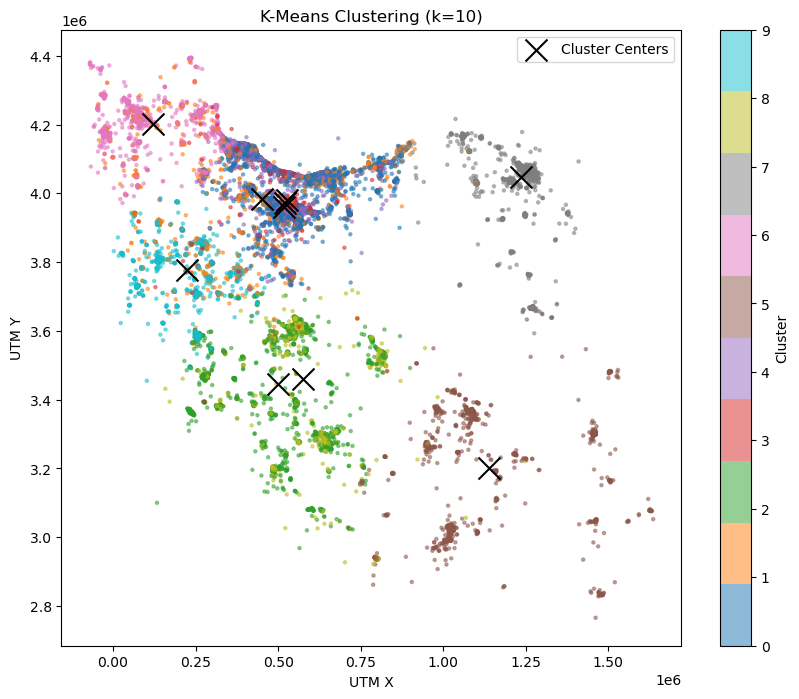

In [190]:
plot_kmeans_clusters(
    df=df_rec,
    centers_df=centers_10_df,
    cluster_col_name="cluster_kmeans_10",
    title="K-Means Clustering (k=10)",
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap="tab10"
)

In [191]:
centers_10_df

,utm_x,utm_y,log_price,center_price
0,525793.39,3981652.48,21.33,1.825906e+09
1,450693.32,3984460.30,19.90,4.372722e+08
2,499633.87,3445695.46,20.89,1.175628e+09
3,516269.63,3959858.75,23.78,2.118736e+10
4,521115.54,3973098.65,22.41,5.375085e+09
5,1139144.64,3199918.54,21.37,1.901560e+09
6,119406.30,4200638.29,21.74,2.764544e+09
7,1234724.23,4047310.95,21.65,2.514684e+09
8,574867.02,3460074.13,22.50,5.918864e+09
9,223763.29,3777384.73,21.69,2.635014e+09


In [192]:
wcss = []

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    print(k, kmeans.inertia_)

1 1037382.0000000009
2 764128.9103253053
3 577580.8225065728
4 421575.41726480686
5 367906.7685683967
6 314756.88974365353
7 271793.05057010276
8 247547.05809533535
9 227269.88630928533
10 207520.5313297779
11 192926.19487567508
12 178320.41335841652
13 165675.71336878277
14 158833.52194939824
15 147400.382352404
16 140817.63563616175
17 134213.66661912634
18 128259.9060146618
19 122862.04051528944
20 117312.96032633212


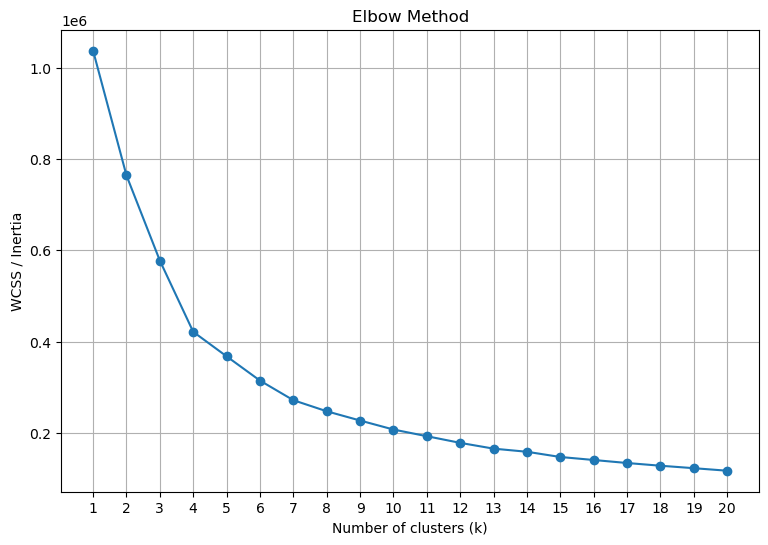

In [193]:
plt.figure(figsize=(9, 6))

plt.plot(list(K_RANGE), wcss, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.xticks(list(K_RANGE))
plt.grid(True)
plt.show()

In [194]:
sample_df = df_rec.sample(n=SCORE_SAMPLE_SIZE, random_state=RANDOM_STATE)

X_sample = sample_df[feature_cols].copy()

sample_scaler = StandardScaler()

X_sample_scaled = sample_scaler.fit_transform(X_sample)

silhouette_scores = []

for k in K_RANGE_SIL:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample_scaled)
    score = silhouette_score(X_sample_scaled, labels)
    
    silhouette_scores.append(score)
    print(k, score)

2 0.39586160806798143
3 0.44087625173836587
4 0.3506960450237424
5 0.36049559089410066
6 0.37143819512104886
7 0.34417241550374633
8 0.34722786212114326
9 0.36640430734115664
10 0.354593100694053
11 0.34816457606156537
12 0.3517385625578836
13 0.35214270612670334
14 0.3425060497014739
15 0.3609849224343766
16 0.34566419920351743
17 0.36626864981092183
18 0.3631593142816182
19 0.34600295202234055
20 0.3489647698313722


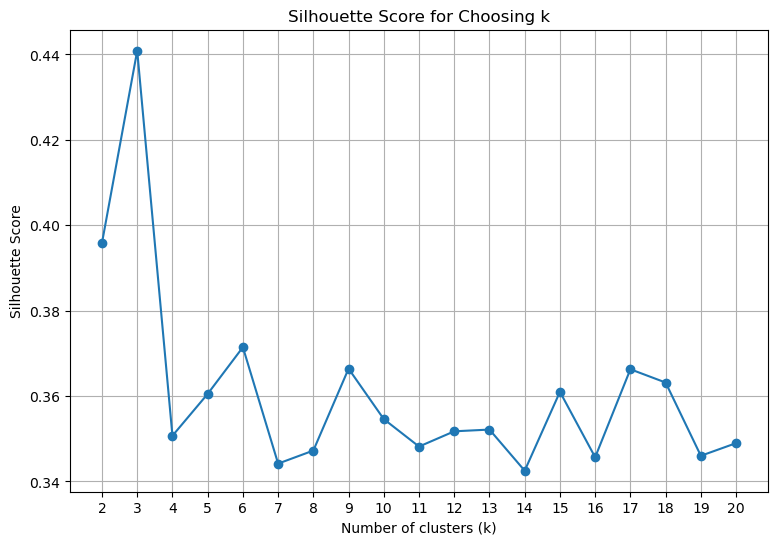

In [195]:
plt.figure(figsize=(9, 6))

plt.plot(list(K_RANGE_SIL), silhouette_scores, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Choosing k")
plt.xticks(list(K_RANGE_SIL))
plt.grid(True)
plt.show()

In [196]:
sample_df = df_rec.sample(n=SCORE_SAMPLE_SIZE, random_state=RANDOM_STATE)

X_sample = sample_df[feature_cols].copy()

sample_scaler = StandardScaler()
X_sample_scaled = sample_scaler.fit_transform(X_sample)

results = []

for k in range(2, 21):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_sample_scaled, labels)
    calinski = calinski_harabasz_score(X_sample_scaled, labels)
    davies = davies_bouldin_score(X_sample_scaled, labels)
    
    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })

k_results = pd.DataFrame(results)
k_results

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,44078.975835,0.395862,7223.143983,1.159490
1,3,33380.817045,0.440876,7973.201223,0.960112
2,4,24259.900524,0.350696,9819.499449,0.923125
3,5,21127.075364,0.360496,9197.493127,0.953658
4,6,18073.873019,0.371438,9276.071589,0.995323
5,7,15530.332157,0.344172,9541.371898,0.927607
6,8,14123.063122,0.347228,9277.353788,0.965185
7,9,12944.190457,0.366404,9084.136631,0.913521
8,10,11810.316920,0.354593,9063.211668,0.937820
9,11,10974.869667,0.348165,8929.279957,0.937921


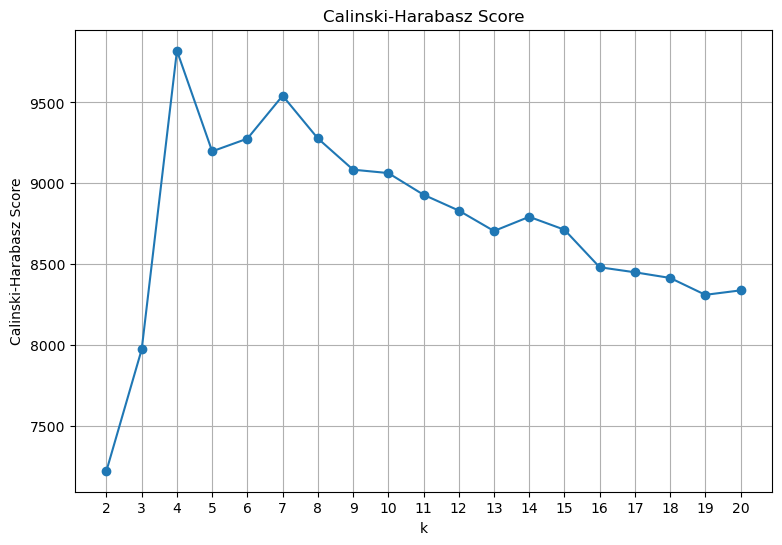

In [197]:
plt.figure(figsize=(9, 6))
plt.plot(k_results["k"], k_results["calinski_harabasz"], marker="o")
plt.xlabel("k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score")
plt.xticks(k_results["k"])
plt.grid(True)
plt.show()

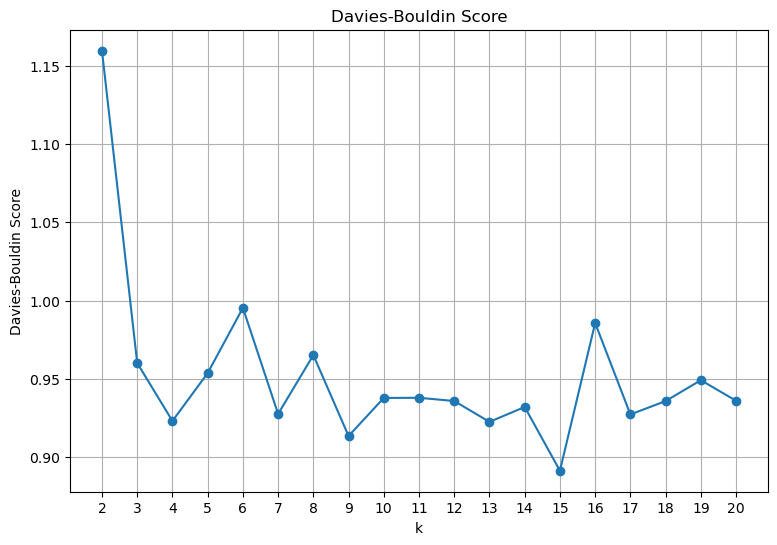

In [198]:
plt.figure(figsize=(9, 6))
plt.plot(k_results["k"], k_results["davies_bouldin"], marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score")
plt.xticks(k_results["k"])
plt.grid(True)
plt.show()

In [199]:
BEST_K = 6

In [200]:
kmeans_best, centers_best_df, counts_best = run_kmeans_clustering(
    df=df_rec,
    X_scaled=X_scaled,
    scaler=scaler,
    feature_cols=feature_cols,
    bool_cols=bool_cols,
    n_clusters=BEST_K,
    cluster_col_name="cluster_kmeans_best",
    random_state=RANDOM_STATE
)

counts_best

cluster_kmeans_best
0     42175
1     91423
2     12645
3    125545
4     47117
5     26889
Name: count, dtype: int64

In [201]:
centers_best_df

,utm_x,utm_y,log_price,center_price
0,181978.78,4105263.81,21.56,2.316362e+09
1,511215.65,3952230.70,23.02,9.987779e+09
2,1118402.41,3193214.33,21.44,2.057720e+09
3,522306.18,3960968.13,21.23,1.657375e+09
4,519116.85,3465554.64,21.72,2.717713e+09
5,1229669.33,4047723.54,21.65,2.526448e+09


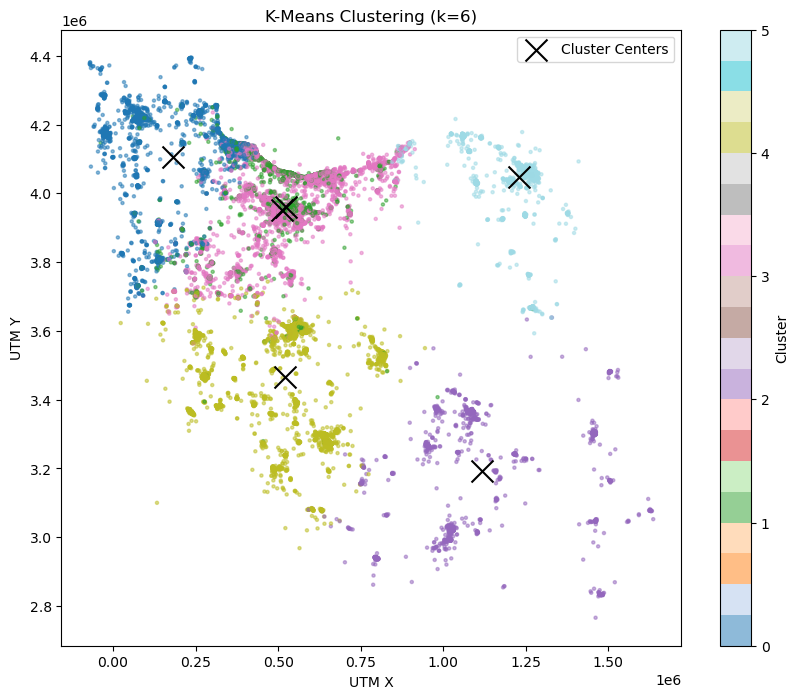

In [202]:
plot_kmeans_clusters(
    df=df_rec,
    centers_df=centers_best_df,
    cluster_col_name="cluster_kmeans_best",
    title=f"K-Means Clustering (k={BEST_K})",
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap="tab20"
)

In [203]:
def summarize_clusters(df, cluster_col_name):
    summary = df.groupby(cluster_col_name).agg(
        count=("price_value", "count"),
        mean_price=("price_value", "mean"),
        median_price=("price_value", "median"),
        mean_building_size=("building_size", "mean"),
        mean_rooms=("rooms_count", "mean"),
        parking_rate=("has_parking", "mean"),
        elevator_rate=("has_elevator", "mean"),
        warehouse_rate=("has_warehouse", "mean"),
        balcony_rate=("has_balcony", "mean")
    )
    
    summary["mean_price_billion"] = summary["mean_price"] / 1e9
    summary["median_price_billion"] = summary["median_price"] / 1e9
    
    return summary.round(2)

In [204]:
summary_10 = summarize_clusters(df_rec, "cluster_kmeans_10")
summary_10

,count,mean_price,median_price,mean_building_size,mean_rooms,parking_rate,elevator_rate,warehouse_rate,balcony_rate,mean_price_billion,median_price_billion
cluster_kmeans_10,,,,,,,,,,,
0,90017,1.935498e+09,1.900000e+09,115.06,1.73,0.61,0.37,0.73,0.56,1.94,1.90
1,19960,5.086689e+08,5.000000e+08,209.30,1.81,0.23,0.12,0.29,0.20,0.51,0.50
2,20341,1.405609e+09,1.380000e+09,185.30,1.85,0.43,0.18,0.38,0.29,1.41,1.38
3,32807,2.635421e+10,1.790000e+10,199.01,2.52,0.80,0.63,0.79,0.58,26.35,17.90
4,76762,5.709809e+09,5.200000e+09,130.83,2.01,0.77,0.57,0.81,0.62,5.71,5.20
5,11820,3.187213e+09,2.100000e+09,189.03,2.07,0.52,0.29,0.40,0.33,3.19,2.10
6,22395,3.733438e+09,2.750000e+09,162.98,1.95,0.56,0.38,0.52,0.47,3.73,2.75
7,26337,4.159596e+09,2.650000e+09,155.34,2.05,0.64,0.40,0.67,0.50,4.16,2.65
8,26720,7.750732e+09,5.200000e+09,176.94,2.36,0.78,0.49,0.73,0.52,7.75,5.20


In [205]:
summary_best = summarize_clusters(df_rec, "cluster_kmeans_best")
summary_best

,count,mean_price,median_price,mean_building_size,mean_rooms,parking_rate,elevator_rate,warehouse_rate,balcony_rate,mean_price_billion,median_price_billion
cluster_kmeans_best,,,,,,,,,,,
0,42175,3.081181e+09,2.500000e+09,159.66,1.93,0.56,0.34,0.56,0.46,3.08,2.50
1,91423,1.389018e+10,8.450000e+09,160.59,2.25,0.79,0.61,0.80,0.60,13.89,8.45
2,12645,4.115875e+09,2.200000e+09,191.29,2.08,0.52,0.30,0.40,0.33,4.12,2.20
3,125545,1.981376e+09,1.900000e+09,126.94,1.75,0.57,0.36,0.68,0.52,1.98,1.90
4,47117,4.125741e+09,2.968000e+09,174.89,2.11,0.63,0.35,0.59,0.42,4.13,2.97
5,26889,4.413487e+09,2.650000e+09,157.19,2.05,0.64,0.39,0.66,0.49,4.41,2.65
